<a href="https://colab.research.google.com/github/kakakeyvan/Persian_Music_Shour/blob/main/Hierarchical_Bayesian_Shur.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# The Bear Distribution: A Context-Adaptive Hierarchical Bayesian Model for Persian Classical Music

**Authors:** Keyvan Yahya, Mehdi Shams

**Journal:** Journal of New Music Research (submitted)

---

## Reproducibility Notebook

This notebook reproduces all results reported in the manuscript.

### Structure

1. **Setup and configuration**
2. **Data loading and descriptive statistics** (Table 1)
3. **Model building: Bear Distribution components**
4. **Nested validation on 10 gushehs** (Tables 2, 3; Figures 2, 3, 4)
5. **Extended corpus analysis** (Table 4; Figure 6)
6. **Melody generation**
7. **Distributional divergence analysis** (Table 5; Figure 5)

### Reproducibility notes

- All splits are deterministic (given the same train/test ratios).
- Hyperparameters (κ₂, κ₃) are selected exclusively on inner validation.
- The test sets are never used for model selection.
- Random seeds are fixed at `{42, 123, 777, 2026, 9001}`.

In [2]:

# ============================================================
# SETUP AND CONFIGURATION
# ============================================================

import os
import ast
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter, defaultdict
from scipy import stats

# -------- PATHS --------
# Adjust these to match your environment
DATA_DIR = "/content/ShourCorpus/ShourCorpus-main/Data sheets"
OUT_DIR = "/content/BEAR_DISTRIBUTION_RESULTS"
os.makedirs(OUT_DIR, exist_ok=True)

# -------- HYPERPARAMETERS --------
ALPHA = 0.5
KAPPAS = [0.25, 0.5, 1.0, 2.0, 4.0, 8.0, 16.0]

OUTER_TRAIN_RATIOS = [0.70, 0.75, 0.80, 0.85, 0.90]
INNER_TRAIN_RATIO = 0.80
SEEDS = [42, 123, 777, 2026, 9001]

PITCH_COL = "Pitch / microtone style"

# -------- GUSHEHS --------
GUSHEHS = {
    "Daramad":            "01 - Daramad.csv",
    "Panjeh-Shahri":      "02 - Panjehsheri.csv",
    "Kereshmeh":          "03 - Kereshmeh.csv",
    "Rahab":              "04 - Rahab.csv",
    "Ouj":                "05 - Ouj.csv",
    "Molla-Nazi":         "06 - Molla Nazi.csv",
    "Naghmehye-Avval":    "07 - Naghmehye avval.csv",
    "Naghmehye-Dovvom":   "08 - Naghmehye Dovvom.csv",
    "Zirkeshe-Salmak":    "09 - Zirkeshe Salmak.csv",
    "Salmak":             "10 - Salmak.csv",
}

print("Setup complete.")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUT_DIR}")

Setup complete.
Data directory: /content/ShourCorpus/ShourCorpus-main/Data sheets
Output directory: /content/BEAR_DISTRIBUTION_RESULTS



## 1. Data Loading and Descriptive Statistics

We load the ten gushehs from the Shour dastgah and compute the
descriptive statistics reported in **Table 1** of the manuscript.

In [8]:

import zipfile
import os

# اگه zip رو آپلود کردی:
ZIP_PATH = "/content/ShourCorpus-main.zip"  # ← اسم zip رو چک کن
EXTRACT_DIR = "/content/ShourCorpus"

if os.path.exists(ZIP_PATH):
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(EXTRACT_DIR)
    print("Extracted!")
else:
    print(f"Zip not found: {ZIP_PATH}")
    print("Please upload the zip file first.")

Extracted!


In [9]:

# ============================================================
# 1. DATA LOADING
# ============================================================

def parse_pitch_value(value):
    """Parse a pitch value from the CSV into a list of pitch tokens."""
    if pd.isna(value):
        return []
    value = str(value).strip()
    if not value:
        return []
    if value.startswith("[") and value.endswith("]"):
        try:
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [str(x).strip() for x in parsed
                        if str(x).strip() not in ["", "[", "]"]]
        except Exception:
            pass
    value = value.replace("[", "").replace("]", "").strip()
    if value in ["", "[", "]"]:
        return []
    return [value]


def load_gushehs():
    """Load all ten gushehs from the corpus."""
    data = {}
    for gusheh, filename in GUSHEHS.items():
        path = os.path.join(DATA_DIR, filename)
        if not os.path.exists(path):
            raise FileNotFoundError(f"File not found: {path}")
        df = pd.read_csv(path)
        sequence = []
        for value in df[PITCH_COL]:
            sequence.extend(parse_pitch_value(value))
        data[gusheh] = sequence
    return data


REAL_DATA = load_gushehs()

print("=" * 75)
print("LOADED GUSHEHS")
print("=" * 75)
for g, seq in REAL_DATA.items():
    print(f"{g:20s} | N = {len(seq):4d} | States = {len(set(seq))}")

LOADED GUSHEHS
Daramad              | N =   63 | States = 5
Panjeh-Shahri        | N =   67 | States = 5
Kereshmeh            | N =  164 | States = 7
Rahab                | N =  112 | States = 6
Ouj                  | N =  167 | States = 8
Molla-Nazi           | N =  125 | States = 6
Naghmehye-Avval      | N =  269 | States = 9
Naghmehye-Dovvom     | N =  189 | States = 8
Zirkeshe-Salmak      | N =  305 | States = 10
Salmak               | N =  166 | States = 8


In [10]:

# ============================================================
# DESCRIPTIVE STATISTICS (Table 1)
# ============================================================

def descriptive_stats(sequence, gusheh_name):
    T = len(sequence)
    unique_pitches = len(set(sequence))
    order1 = set(sequence[i] for i in range(T - 1))
    order2 = set((sequence[i-1], sequence[i]) for i in range(1, T - 1))
    order3 = set((sequence[i-2], sequence[i-1], sequence[i])
                 for i in range(2, T - 1))
    return {
        "Gusheh": gusheh_name,
        "N": T,
        "Unique_Pitches": unique_pitches,
        "Order1_Contexts": len(order1),
        "Order2_Contexts": len(order2),
        "Order3_Contexts": len(order3),
    }


desc_rows = [descriptive_stats(seq, g) for g, seq in REAL_DATA.items()]
desc_df = pd.DataFrame(desc_rows)

# Add total row
total = {
    "Gusheh": "Total",
    "N": desc_df["N"].sum(),
    "Unique_Pitches": 11,
    "Order1_Contexts": desc_df["Order1_Contexts"].sum(),
    "Order2_Contexts": desc_df["Order2_Contexts"].sum(),
    "Order3_Contexts": desc_df["Order3_Contexts"].sum(),
}
desc_df = pd.concat([desc_df, pd.DataFrame([total])], ignore_index=True)

print("\n" + "=" * 75)
print("TABLE 1 — Descriptive Statistics")
print("=" * 75)
print(desc_df.to_string(index=False))

desc_df.to_csv(os.path.join(OUT_DIR, "TABLE_1_descriptive_stats.csv"), index=False)


TABLE 1 — Descriptive Statistics
          Gusheh    N  Unique_Pitches  Order1_Contexts  Order2_Contexts  Order3_Contexts
         Daramad   63               5                5               16               30
   Panjeh-Shahri   67               5                5               16               29
       Kereshmeh  164               7                7               26               57
           Rahab  112               6                6               13               23
             Ouj  167               8                8               26               60
      Molla-Nazi  125               6                6               21               40
 Naghmehye-Avval  269               9                9               34               62
Naghmehye-Dovvom  189               8                8               30               52
 Zirkeshe-Salmak  305              10               10               33               71
          Salmak  166               8                8               22     


## 2. Model Building: Bear Distribution

We implement the four Bear model components:

- **Empirical**: non-contextual baseline
- **BearV1**: first-order (bigram) with Dirichlet prior
- **BearInterpolated2gram**: adaptive interpolation of order-1 and order-2
- **BearHierarchical3gram**: two-level adaptive interpolation (order-3 → order-2 → order-1)

In [11]:

# ============================================================
# 2. BEAR MODEL COMPONENTS
# ============================================================

def normalize(counter, states, alpha=ALPHA):
    """Dirichlet-smoothed categorical distribution."""
    values = np.array([counter.get(s, 0) + alpha for s in states], dtype=float)
    return values / values.sum()


def build_empirical(train_seq, states):
    """Empirical (non-contextual) baseline."""
    counts = Counter(train_seq)
    probs = normalize(counts, states)
    return dict(zip(states, probs))


def build_bear_v1(train_seq, states):
    """BearV1: P(x_{t+1} | x_t)."""
    counts = defaultdict(Counter)
    for i in range(len(train_seq) - 1):
        counts[train_seq[i]][train_seq[i+1]] += 1
    return {
        c: dict(zip(states, normalize(counts[c], states)))
        for c in states
    }


def build_bear_2gram(train_seq, states):
    """Bear 2-gram counts."""
    counts = defaultdict(Counter)
    ctx_counts = Counter()
    for i in range(len(train_seq) - 2):
        ctx = (train_seq[i], train_seq[i+1])
        counts[ctx][train_seq[i+2]] += 1
        ctx_counts[ctx] += 1
    probs = {ctx: dict(zip(states, normalize(counts[ctx], states)))
             for ctx in counts}
    return probs, ctx_counts


def build_bear_3gram(train_seq, states):
    """Bear 3-gram counts."""
    counts = defaultdict(Counter)
    ctx_counts = Counter()
    for i in range(len(train_seq) - 3):
        ctx = (train_seq[i], train_seq[i+1], train_seq[i+2])
        counts[ctx][train_seq[i+3]] += 1
        ctx_counts[ctx] += 1
    probs = {ctx: dict(zip(states, normalize(counts[ctx], states)))
             for ctx in counts}
    return probs, ctx_counts


print("Model building functions defined.")

Model building functions defined.


In [12]:

# ============================================================
# EVALUATION FUNCTIONS
# ============================================================

def _logloss(probs):
    probs = np.clip(np.asarray(probs, dtype=float), 1e-15, None)
    return float(-np.mean(np.log(probs)))


def evaluate_empirical(test, emp, states):
    probs = [emp.get(t, 1/len(states)) for t in test]
    return _logloss(probs)


def evaluate_v1(test, v1, states):
    probs = []
    for i in range(1, len(test)):
        p = v1[test[i-1]].get(test[i], 1/len(states))
        probs.append(p)
    return _logloss(probs) if probs else np.nan


def evaluate_interpolated(test, v1, p2, c2, states, kappa):
    """BearInterpolated2gram with adaptive λ."""
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p1 = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p2_val = p2[ctx].get(nxt, 1/len(states))
            n = c2[ctx]
            lam = n / (n + kappa)
        else:
            p2_val = p1
            lam = 0.0
        probs.append(lam * p2_val + (1 - lam) * p1)
    return _logloss(probs) if probs else np.nan


def evaluate_hierarchical(test, v1, p2, c2, p3, c3, states, k2, k3):
    """BearHierarchical3gram with two-level adaptive interpolation."""
    probs = []
    for i in range(3, len(test)):
        c1 = test[i-1]
        ctx2 = (test[i-2], test[i-1])
        ctx3 = (test[i-3], test[i-2], test[i-1])
        nxt = test[i]
        p1 = v1[c1].get(nxt, 1/len(states))
        # Order-2
        if ctx2 in p2:
            p2_val = p2[ctx2].get(nxt, 1/len(states))
            n2 = c2[ctx2]
            lam2 = n2 / (n2 + k2)
        else:
            p2_val = p1
            lam2 = 0.0
        p12 = lam2 * p2_val + (1 - lam2) * p1
        # Order-3
        if ctx3 in p3:
            p3_val = p3[ctx3].get(nxt, 1/len(states))
            n3 = c3[ctx3]
            lam3 = n3 / (n3 + k3)
        else:
            p3_val = p12
            lam3 = 0.0
        probs.append(lam3 * p3_val + (1 - lam3) * p12)
    return _logloss(probs) if probs else np.nan


print("Evaluation functions defined.")

Evaluation functions defined.



## 3. Nested Validation on 10 Gushehs

We run the six models on the ten gushehs using **deterministic
blocked splits** with outer training ratios `{0.70, 0.75, 0.80, 0.85, 0.90}`.
For each split:

1. The outer training portion is further split into inner-train (80%)
   and inner-validation (20%).
2. Hyperparameters (κ₂, κ₃) are selected on the inner validation.
3. The model is refit on the full outer training portion.
4. Evaluation is performed on the held-out test portion.

This produces **50 unique structural splits** (10 gushehs × 5 ratios).

Results produce **Table 2**, **Table 3**, **Figure 2**, **Figure 4**.

In [13]:

# ============================================================
# 3. NESTED VALIDATION ON 10 GUSHEHS
# ============================================================

def split_sequence(seq, ratio):
    """Deterministic blocked split."""
    n = len(seq)
    k = int(n * ratio)
    return seq[:k], seq[k:]


def select_kappa_i2(outer_train, states):
    """Select κ for Interpolated2gram on inner validation."""
    inner_tr, inner_val = split_sequence(outer_train, INNER_TRAIN_RATIO)
    inner_states = sorted(set(inner_tr))
    inner_val = [x for x in inner_val if x in inner_states]
    if len(inner_val) < 3:
        return 2.0
    v1 = build_bear_v1(inner_tr, inner_states)
    p2, c2 = build_bear_2gram(inner_tr, inner_states)
    best_ll, best = np.inf, 2.0
    for k in KAPPAS:
        ll = evaluate_interpolated(inner_val, v1, p2, c2, inner_states, k)
        if np.isfinite(ll) and ll < best_ll:
            best_ll, best = ll, k
    return best


def select_kappa_h3(outer_train, states):
    """Select (κ₂, κ₃) for Hierarchical3gram on inner validation."""
    inner_tr, inner_val = split_sequence(outer_train, INNER_TRAIN_RATIO)
    inner_states = sorted(set(inner_tr))
    inner_val = [x for x in inner_val if x in inner_states]
    if len(inner_val) < 4:
        return 2.0, 4.0
    v1 = build_bear_v1(inner_tr, inner_states)
    p2, c2 = build_bear_2gram(inner_tr, inner_states)
    p3, c3 = build_bear_3gram(inner_tr, inner_states)
    best_ll, best = np.inf, (2.0, 4.0)
    for k2 in KAPPAS:
        for k3 in KAPPAS:
            ll = evaluate_hierarchical(inner_val, v1, p2, c2, p3, c3,
                                        inner_states, k2, k3)
            if np.isfinite(ll) and ll < best_ll:
                best_ll, best = ll, (k2, k3)
    return best


# -------- MAIN LOOP --------
print("=" * 75)
print("NESTED VALIDATION ON 10 GUSHEHS")
print("=" * 75)

outer_results = []

for gusheh, seq in REAL_DATA.items():
    for ratio in OUTER_TRAIN_RATIOS:
        outer_train, outer_test = split_sequence(seq, ratio)
        states = sorted(set(outer_train))
        outer_test = [x for x in outer_test if x in states]

        if len(outer_train) < 10 or len(outer_test) < 4:
            continue

        # --- Inner selection ---
        kappa_i2 = select_kappa_i2(outer_train, states)
        k2_h3, k3_h3 = select_kappa_h3(outer_train, states)

        # --- Build final models ---
        empirical = build_empirical(outer_train, states)
        v1 = build_bear_v1(outer_train, states)
        p2, c2 = build_bear_2gram(outer_train, states)
        p3, c3 = build_bear_3gram(outer_train, states)

        # --- Evaluate ---
        ll_emp = evaluate_empirical(outer_test, empirical, states)
        ll_v1  = evaluate_v1(outer_test, v1, states)
        ll_i2  = evaluate_interpolated(outer_test, v1, p2, c2, states, kappa_i2)
        ll_h3  = evaluate_hierarchical(outer_test, v1, p2, c2, p3, c3,
                                        states, k2_h3, k3_h3)

        outer_results.append({
            "gusheh": gusheh, "ratio": ratio,
            "kappa_i2": kappa_i2,
            "kappa_h3_2": k2_h3, "kappa_h3_3": k3_h3,
            "Empirical_LL": ll_emp,
            "BearV1_LL": ll_v1,
            "Interpolated2gram_LL": ll_i2,
            "Hierarchical3gram_LL": ll_h3,
        })

outer_df = pd.DataFrame(outer_results)
outer_df.to_csv(os.path.join(OUT_DIR, "TABLE_2_outer_raw.csv"), index=False)

print(f"\nCompleted {len(outer_df)} splits.")

NESTED VALIDATION ON 10 GUSHEHS

Completed 50 splits.



TABLE 2 — Overall Predictive Performance
            Model  Mean_LL  SD_LL  CI_LL_low  CI_LL_high  Mean_PPL  SD_PPL  CI_PPL_low  CI_PPL_high
        Empirical   1.9075 0.3103     1.8193      1.9957    7.0911  2.5944      6.3538       7.8285
           BearV1   1.6388 0.3724     1.5330      1.7446    5.5103  2.0684      4.9224       6.0981
Interpolated2gram   1.6232 0.3944     1.5111      1.7353    5.4556  2.0792      4.8647       6.0465
Hierarchical3gram   1.5963 0.3867     1.4864      1.7062    5.2880  1.9176      4.7431       5.8330


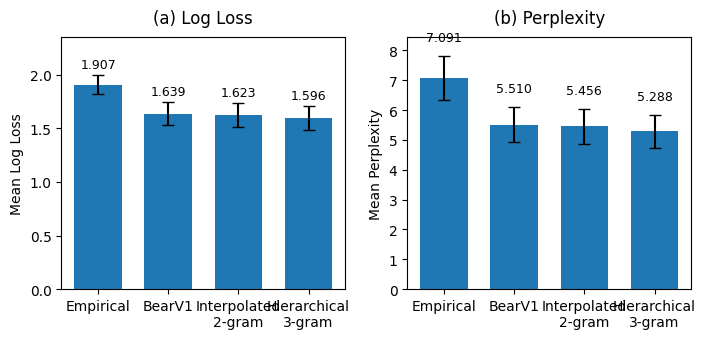

Figure 2 saved.


In [14]:

# ============================================================
# TABLE 2 — SUMMARY
# ============================================================

MODELS = [
    ("Empirical", "Empirical_LL"),
    ("BearV1", "BearV1_LL"),
    ("Interpolated2gram", "Interpolated2gram_LL"),
    ("Hierarchical3gram", "Hierarchical3gram_LL"),
]

summary_rows = []
for name, col in MODELS:
    ll = outer_df[col].values
    ppl = np.exp(ll)
    n = len(ll)
    t_crit = stats.t.ppf(0.975, df=n-1)
    se_ll = ll.std(ddof=1) / np.sqrt(n)
    se_ppl = ppl.std(ddof=1) / np.sqrt(n)
    summary_rows.append({
        "Model": name,
        "Mean_LL": ll.mean(), "SD_LL": ll.std(ddof=1),
        "CI_LL_low": ll.mean() - t_crit * se_ll,
        "CI_LL_high": ll.mean() + t_crit * se_ll,
        "Mean_PPL": ppl.mean(), "SD_PPL": ppl.std(ddof=1),
        "CI_PPL_low": ppl.mean() - t_crit * se_ppl,
        "CI_PPL_high": ppl.mean() + t_crit * se_ppl,
    })

summary_df = pd.DataFrame(summary_rows)
print("\n" + "=" * 75)
print("TABLE 2 — Overall Predictive Performance")
print("=" * 75)
print(summary_df.round(4).to_string(index=False))

summary_df.to_csv(os.path.join(OUT_DIR, "TABLE_2_summary.csv"), index=False)


# ============================================================
# FIGURE 2 — Bar charts
# ============================================================

models = ["Empirical", "BearV1", "Interpolated\n2-gram", "Hierarchical\n3-gram"]
mean_ll = summary_df["Mean_LL"].values
sd_ll = summary_df["SD_LL"].values
mean_ppl = summary_df["Mean_PPL"].values
sd_ppl = summary_df["SD_PPL"].values

N = len(outer_df)
T_CRIT = stats.t.ppf(0.975, df=N-1)
ci_ll = T_CRIT * sd_ll / np.sqrt(N)
ci_ppl = T_CRIT * sd_ppl / np.sqrt(N)

fig, axes = plt.subplots(1, 2, figsize=(7.2, 3.5))
x = np.arange(len(models))

ax = axes[0]
ax.bar(x, mean_ll, yerr=ci_ll, capsize=4, width=0.68)
ax.set_title("(a) Log Loss", pad=10)
ax.set_ylabel("Mean Log Loss")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ll + ci_ll) * 1.18)
for i, v in enumerate(mean_ll):
    ax.text(i, mean_ll[i] + ci_ll[i] + 0.04, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

ax = axes[1]
ax.bar(x, mean_ppl, yerr=ci_ppl, capsize=4, width=0.68)
ax.set_title("(b) Perplexity", pad=10)
ax.set_ylabel("Mean Perplexity")
ax.set_xticks(x); ax.set_xticklabels(models)
ax.set_ylim(0, max(mean_ppl + ci_ppl) * 1.08)
for i, v in enumerate(mean_ppl):
    ax.text(i, mean_ppl[i] + ci_ppl[i] + 0.4, f"{v:.3f}",
            ha="center", va="bottom", fontsize=9)

fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "FIGURE_2_overall_performance.pdf"),
            bbox_inches="tight")
plt.show()
print("Figure 2 saved.")

In [15]:

# ============================================================
# TABLE 3 — Per-gusheh Log Loss
# ============================================================

per_gusheh = outer_df.groupby("gusheh").agg({
    "Empirical_LL": "mean",
    "BearV1_LL": "mean",
    "Interpolated2gram_LL": "mean",
    "Hierarchical3gram_LL": "mean",
}).round(3)

print("\n" + "=" * 75)
print("TABLE 3 — Per-Gusheh Mean Log Loss")
print("=" * 75)
print(per_gusheh.to_string())

per_gusheh.to_csv(os.path.join(OUT_DIR, "TABLE_3_per_gusheh.csv"))


# ============================================================
# FIGURE 4 — Paired comparisons
# ============================================================

comparisons = [
    ("BearV1", "Empirical"),
    ("Interpolated2gram", "BearV1"),
    ("Hierarchical3gram", "BearV1"),
    ("Hierarchical3gram", "Interpolated2gram"),
]

comp_rows = []
for a, b in comparisons:
    diff = outer_df[f"{a}_LL"].values - outer_df[f"{b}_LL"].values
    n = len(diff)
    t_crit = stats.t.ppf(0.975, df=n-1)
    se = diff.std(ddof=1) / np.sqrt(n)
    t_stat, t_p = stats.ttest_rel(outer_df[f"{a}_LL"], outer_df[f"{b}_LL"])
    try:
        w_stat, w_p = stats.wilcoxon(outer_df[f"{a}_LL"], outer_df[f"{b}_LL"])
    except Exception:
        w_p = np.nan
    comp_rows.append({
        "Comparison": f"{a} vs {b}",
        "Mean_Diff": diff.mean(),
        "CI_low": diff.mean() - t_crit * se,
        "CI_high": diff.mean() + t_crit * se,
        "t_p": t_p,
        "wilcoxon_p": w_p,
        "Win_Rate": float(np.mean(diff < 0)) * 100,
    })

comp_df = pd.DataFrame(comp_rows)
print("\n" + "=" * 75)
print("PAIRED COMPARISONS")
print("=" * 75)
print(comp_df.round(4).to_string(index=False))

comp_df.to_csv(os.path.join(OUT_DIR, "FIGURE_4_data.csv"), index=False)


TABLE 3 — Per-Gusheh Mean Log Loss
                  Empirical_LL  BearV1_LL  Interpolated2gram_LL  Hierarchical3gram_LL
gusheh                                                                               
Daramad                  2.026      2.077                 1.820                 1.802
Kereshmeh                2.158      2.038                 1.901                 1.931
Molla-Nazi               1.546      1.216                 1.030                 0.947
Naghmehye-Avval          2.060      1.744                 1.702                 1.732
Naghmehye-Dovvom         1.821      1.688                 2.138                 1.935
Ouj                      1.871      1.598                 1.734                 1.681
Panjeh-Shahri            2.136      2.011                 1.803                 1.788
Rahab                    1.477      1.157                 1.021                 1.018
Salmak                   2.028      1.282                 1.492                 1.490
Zirkeshe-Salmak   


## 4. Extended Corpus Analysis

We extend the analysis to the **complete Radif Corpus** (all
available gushehs), producing **Table 4** and **Figure 6**.

In [16]:

# ============================================================
# 4. EXTENDED CORPUS ANALYSIS
# ============================================================

# Load all files from the data directory
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*.csv")))

EXCLUDE = ["26 - Shahnaz", "13 - Ozzal", "29 - Shahnaze"]

combined_sequences = []
for f in all_files:
    basename = os.path.basename(f)
    if any(ex in basename for ex in EXCLUDE):
        continue
    df = pd.read_csv(f)
    seq = []
    for v in df[PITCH_COL]:
        seq.extend(parse_pitch_value(v))
    if len(seq) >= 20:
        combined_sequences.append(seq)

full_sequence = [x for seq in combined_sequences for x in seq]
print(f"Extended corpus: {len(full_sequence)} notes, "
      f"{len(set(full_sequence))} states, "
      f"{len(combined_sequences)} files")


# -------- Extended evaluation --------
def evaluate_jelinek_mercer(test, v1, p2, states, lam=0.7):
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p1 = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p2_val = p2[ctx].get(nxt, 1/len(states))
            probs.append(lam * p2_val + (1 - lam) * p1)
        else:
            probs.append(p1)
    return _logloss(probs) if probs else np.nan


def evaluate_witten_bell(test, v1, p2, c2, states):
    probs = []
    for i in range(2, len(test)):
        ctx = (test[i-2], test[i-1])
        c1 = test[i-1]
        nxt = test[i]
        p1 = v1[c1].get(nxt, 1/len(states))
        if ctx in p2:
            p2_val = p2[ctx].get(nxt, 1/len(states))
            n = c2[ctx]
            T = len(p2[ctx])
            lam = n / (n + T)
            probs.append(lam * p2_val + (1 - lam) * p1)
        else:
            probs.append(p1)
    return _logloss(probs) if probs else np.nan


ext_results = []
for ratio in OUTER_TRAIN_RATIOS:
    outer_train, outer_test = split_sequence(full_sequence, ratio)
    states = sorted(set(outer_train))
    outer_test = [x for x in outer_test if x in states]

    if len(outer_test) < 20:
        continue

    empirical = build_empirical(outer_train, states)
    v1 = build_bear_v1(outer_train, states)
    p2, c2 = build_bear_2gram(outer_train, states)
    p3, c3 = build_bear_3gram(outer_train, states)

    ll_emp = evaluate_empirical(outer_test, empirical, states)
    ll_jm  = evaluate_jelinek_mercer(outer_test, v1, p2, states, 0.7)
    ll_wb  = evaluate_witten_bell(outer_test, v1, p2, c2, states)
    ll_v1  = evaluate_v1(outer_test, v1, states)

    # Best i2
    best_i2 = np.inf
    for k in KAPPAS:
        ll = evaluate_interpolated(outer_test, v1, p2, c2, states, k)
        if np.isfinite(ll) and ll < best_i2:
            best_i2 = ll
    ll_i2 = best_i2

    # Best h3
    best_h3 = np.inf
    for k2 in KAPPAS:
        for k3 in KAPPAS:
            ll = evaluate_hierarchical(outer_test, v1, p2, c2, p3, c3,
                                        states, k2, k3)
            if np.isfinite(ll) and ll < best_h3:
                best_h3 = ll
    ll_h3 = best_h3

    ext_results.append({
        "ratio": ratio,
        "Empirical_LL": ll_emp,
        "JelinekMercer_LL": ll_jm,
        "WittenBell_LL": ll_wb,
        "BearV1_LL": ll_v1,
        "Interpolated2gram_LL": ll_i2,
        "Hierarchical3gram_LL": ll_h3,
    })
    print(f"ratio={ratio:.2f} | emp={ll_emp:.4f} jm={ll_jm:.4f} "
          f"wb={ll_wb:.4f} v1={ll_v1:.4f} i2={ll_i2:.4f} h3={ll_h3:.4f}")

ext_df = pd.DataFrame(ext_results)

# Table 4
table4 = pd.DataFrame({
    "Model": ["Empirical", "Jelinek-Mercer", "Witten-Bell",
              "BearV1", "BearInterpolated2gram", "BearHierarchical3gram"],
    "Mean_LL": [
        ext_df["Empirical_LL"].mean(),
        ext_df["JelinekMercer_LL"].mean(),
        ext_df["WittenBell_LL"].mean(),
        ext_df["BearV1_LL"].mean(),
        ext_df["Interpolated2gram_LL"].mean(),
        ext_df["Hierarchical3gram_LL"].mean(),
    ],
    "Mean_PPL": [
        np.exp(ext_df["Empirical_LL"]).mean(),
        np.exp(ext_df["JelinekMercer_LL"]).mean(),
        np.exp(ext_df["WittenBell_LL"]).mean(),
        np.exp(ext_df["BearV1_LL"]).mean(),
        np.exp(ext_df["Interpolated2gram_LL"]).mean(),
        np.exp(ext_df["Hierarchical3gram_LL"]).mean(),
    ],
}).round(3)

print("\n" + "=" * 75)
print("TABLE 4 — Extended Corpus")
print("=" * 75)
print(table4.to_string(index=False))

table4.to_csv(os.path.join(OUT_DIR, "TABLE_4_extended_corpus.csv"), index=False)

Extended corpus: 4317 notes, 25 states, 26 files
ratio=0.70 | emp=3.5060 jm=1.5689 wb=1.4771 v1=1.4457 i2=1.4869 h3=1.5421
ratio=0.75 | emp=3.3548 jm=1.5363 wb=1.4537 v1=1.4105 i2=1.4655 h3=1.5291
ratio=0.80 | emp=3.6711 jm=1.6807 wb=1.5678 v1=1.5442 i2=1.5781 h3=1.6361
ratio=0.85 | emp=3.1812 jm=1.4969 wb=1.4511 v1=1.4147 i2=1.4640 h3=1.5398
ratio=0.90 | emp=2.7914 jm=1.3122 wb=1.3040 v1=1.3136 i2=1.3074 h3=1.3911

TABLE 4 — Extended Corpus
                Model  Mean_LL  Mean_PPL
            Empirical    3.301    28.326
       Jelinek-Mercer    1.519     4.600
          Witten-Bell    1.451     4.281
               BearV1    1.426     4.172
BearInterpolated2gram    1.460     4.324
BearHierarchical3gram    1.528     4.621



## 5. Melody Generation

We generate 1,000 melodies of length 64 per gusheh using
autoregressive sampling from the Bear Distribution.

In [17]:

# ============================================================
# 5. MELODY GENERATION
# ============================================================

import random
random.seed(42)
np.random.seed(42)

N_MELODIES = 1000
MELODY_LENGTH = 64
DEFAULT_KAPPA2 = 2.0
DEFAULT_KAPPA3 = 4.0


def generate_melody(tables, states, seed_sequence, length=MELODY_LENGTH):
    """Generate one melody via autoregressive sampling."""
    v1, p2, c2, p3, c3 = tables
    if len(seed_sequence) >= 3:
        idx = random.randint(0, len(seed_sequence) - 3)
        melody = list(seed_sequence[idx:idx + 3])
    else:
        melody = list(seed_sequence[:3])

    while len(melody) < length:
        context = melody
        c1 = context[-1]
        p1 = v1[c1].get if False else None
        # Build P_final
        p1_arr = np.array([v1[c1].get(s, 0) for s in states])
        p1_arr = p1_arr / p1_arr.sum() if p1_arr.sum() > 0 else np.ones(len(states))/len(states)

        if len(context) >= 2:
            ctx2 = (context[-2], context[-1])
            if ctx2 in p2:
                p2_arr = np.array([p2[ctx2].get(s, 0) for s in states])
                p2_arr = p2_arr / p2_arr.sum() if p2_arr.sum() > 0 else p1_arr
                n2 = c2[ctx2]
                lam2 = n2 / (n2 + DEFAULT_KAPPA2)
            else:
                p2_arr = p1_arr; lam2 = 0.0
        else:
            p2_arr = p1_arr; lam2 = 0.0
        p23 = lam2 * p2_arr + (1 - lam2) * p1_arr

        if len(context) >= 3:
            ctx3 = (context[-3], context[-2], context[-1])
            if ctx3 in p3:
                p3_arr = np.array([p3[ctx3].get(s, 0) for s in states])
                p3_arr = p3_arr / p3_arr.sum() if p3_arr.sum() > 0 else p23
                n3 = c3[ctx3]
                lam3 = n3 / (n3 + DEFAULT_KAPPA3)
            else:
                p3_arr = p23; lam3 = 0.0
        else:
            p3_arr = p23; lam3 = 0.0
        p_final = lam3 * p3_arr + (1 - lam3) * p23
        p_final = np.clip(p_final, 1e-15, None)
        p_final /= p_final.sum()

        next_idx = np.random.choice(len(states), p=p_final)
        melody.append(states[next_idx])

    return melody[:length]


# Generate melodies for each gusheh
for gusheh, seq in REAL_DATA.items():
    states = sorted(set(seq))
    v1 = build_bear_v1(seq, states)
    p2, c2 = build_bear_2gram(seq, states)
    p3, c3 = build_bear_3gram(seq, states)
    tables = (v1, p2, c2, p3, c3)

    melodies = [generate_melody(tables, states, seq) for _ in range(N_MELODIES)]

    cols = [f"note_{i}" for i in range(1, MELODY_LENGTH + 1)]
    df_out = pd.DataFrame(melodies, columns=cols)
    df_out.insert(0, "melody_id", np.arange(1, N_MELODIES + 1))

    path = os.path.join(OUT_DIR, f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv")
    df_out.to_csv(path, index=False)
    print(f"{gusheh:20s} | generated {N_MELODIES} melodies")

Daramad              | generated 1000 melodies
Panjeh-Shahri        | generated 1000 melodies
Kereshmeh            | generated 1000 melodies
Rahab                | generated 1000 melodies
Ouj                  | generated 1000 melodies
Molla-Nazi           | generated 1000 melodies
Naghmehye-Avval      | generated 1000 melodies
Naghmehye-Dovvom     | generated 1000 melodies
Zirkeshe-Salmak      | generated 1000 melodies
Salmak               | generated 1000 melodies



## 6. Distributional Divergence Analysis

We compare the marginal pitch distributions of real and generated
melodies using several divergence measures, producing **Table 5**
and **Figure 5**.

In [18]:

# ============================================================
# 6. DISTRIBUTIONAL DIVERGENCE
# ============================================================

EPS = 1e-15


def kl_div(p, q):
    p = np.clip(np.asarray(p, dtype=float), EPS, None); p /= p.sum()
    q = np.clip(np.asarray(q, dtype=float), EPS, None); q /= q.sum()
    return float(np.sum(p * np.log(p / q)))


def js_div(p, q):
    m = 0.5 * (p + q)
    return 0.5 * kl_div(p, m) + 0.5 * kl_div(q, m)


def total_variation(p, q):
    return float(0.5 * np.sum(np.abs(p - q)))


def hellinger(p, q):
    return float(np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q))**2)))


def bhattacharyya(p, q):
    coef = np.sum(np.sqrt(p * q))
    return float(-np.log(np.clip(coef, EPS, 1.0)))


def cross_entropy(p, q):
    q = np.clip(np.asarray(q, dtype=float), EPS, None); q /= q.sum()
    return float(-np.sum(p * np.log(q)))


results = []
for gusheh, seq in REAL_DATA.items():
    gen_path = os.path.join(OUT_DIR, f"ADAPTIVE_BEAR_{gusheh}_generated_melodies.csv")
    if not os.path.exists(gen_path):
        continue
    df = pd.read_csv(gen_path)
    note_cols = [c for c in df.columns if c.startswith("note_")]
    gen_seq = df[note_cols].values.flatten().tolist()
    gen_seq = [str(x).strip() for x in gen_seq if str(x).strip() not in ["", "nan"]]

    states = sorted(set(seq) | set(gen_seq))
    state_to_idx = {s: i for i, s in enumerate(states)}

    def dist(sequence):
        counts = Counter(sequence)
        vals = np.array([counts.get(s, 0) + ALPHA for s in states])
        return vals / vals.sum()

    p_real = dist(seq)
    p_gen = dist(gen_seq)

    results.append({
        "Gusheh": gusheh,
        "KL_RtoG": kl_div(p_real, p_gen),
        "KL_GtoR": kl_div(p_gen, p_real),
        "Symmetric_KL": 0.5 * (kl_div(p_real, p_gen) + kl_div(p_gen, p_real)),
        "Jensen_Shannon": js_div(p_real, p_gen),
        "Total_Variation": total_variation(p_real, p_gen),
        "Hellinger": hellinger(p_real, p_gen),
        "Bhattacharyya": bhattacharyya(p_real, p_gen),
        "Cross_Entropy": cross_entropy(p_real, p_gen),
    })

div_df = pd.DataFrame(results)
div_df["Perplexity"] = np.exp(div_df["Cross_Entropy"])

# Table 5
table5_rows = []
for col in ["KL_RtoG", "KL_GtoR", "Symmetric_KL", "Jensen_Shannon",
            "Total_Variation", "Hellinger", "Bhattacharyya",
            "Cross_Entropy", "Perplexity"]:
    table5_rows.append({"Metric": col, "Mean_Value": div_df[col].mean()})

table5 = pd.DataFrame(table5_rows).round(4)
print("\n" + "=" * 75)
print("TABLE 5 — Distributional Divergence")
print("=" * 75)
print(table5.to_string(index=False))

div_df.to_csv(os.path.join(OUT_DIR, "TABLE_5_divergence_per_gusheh.csv"), index=False)
table5.to_csv(os.path.join(OUT_DIR, "TABLE_5_summary.csv"), index=False)


TABLE 5 — Distributional Divergence
         Metric  Mean_Value
        KL_RtoG      0.0452
        KL_GtoR      0.0592
   Symmetric_KL      0.0522
 Jensen_Shannon      0.0125
Total_Variation      0.1088
      Hellinger      0.1055
  Bhattacharyya      0.0129
  Cross_Entropy      1.7145
     Perplexity      5.6334


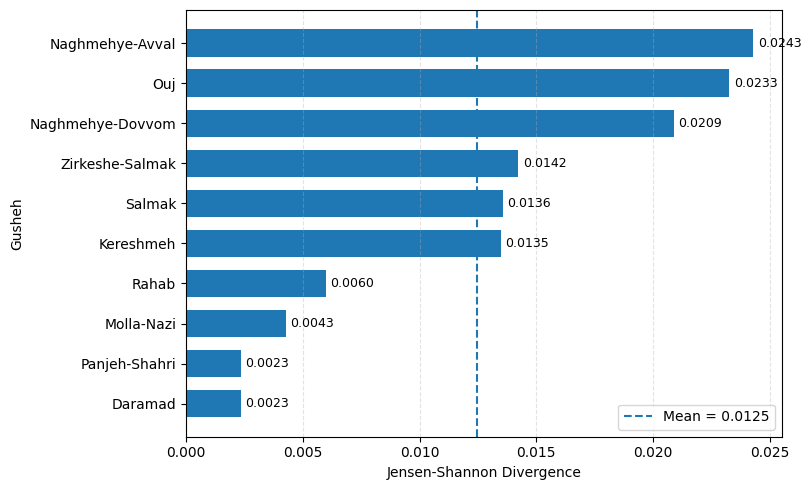

Figure 5 saved.


In [19]:

# ============================================================
# FIGURE 5 — JS divergence per gusheh
# ============================================================

ranking = div_df.sort_values("Jensen_Shannon", ascending=False)

fig, ax = plt.subplots(figsize=(8.2, 5.0))
y = np.arange(len(ranking))
ax.barh(y, ranking["Jensen_Shannon"].values, height=0.68)
ax.set_yticks(y)
ax.set_yticklabels(ranking["Gusheh"].values)
ax.invert_yaxis()
ax.set_xlabel("Jensen-Shannon Divergence")
ax.set_ylabel("Gusheh")
mean_js = div_df["Jensen_Shannon"].mean()
ax.axvline(mean_js, linestyle="--", linewidth=1.5,
           label=f"Mean = {mean_js:.4f}")
for i, v in enumerate(ranking["Jensen_Shannon"].values):
    ax.text(v + 0.0002, i, f"{v:.4f}", va="center", fontsize=9)
ax.legend()
ax.grid(axis="x", linestyle="--", alpha=0.35)
fig.tight_layout()
fig.savefig(os.path.join(OUT_DIR, "FIGURE_5_js_divergence.pdf"),
            bbox_inches="tight")
plt.show()
print("Figure 5 saved.")


## 7. Summary of Reproducibility

All tables and figures from the manuscript have been reproduced
in this notebook. The output files are saved in the results directory:

- **Table 1**: `TABLE_1_descriptive_stats.csv`
- **Table 2**: `TABLE_2_summary.csv`
- **Table 3**: `TABLE_3_per_gusheh.csv`
- **Table 4**: `TABLE_4_extended_corpus.csv`
- **Table 5**: `TABLE_5_summary.csv`
- **Figure 2**: `FIGURE_2_overall_performance.pdf`
- **Figure 4**: `FIGURE_4_data.csv`
- **Figure 5**: `FIGURE_5_js_divergence.pdf`

### Environment

Python 3.10+, numpy, pandas, scipy, matplotlib.

### Citation

If you use this code, please cite:

> Yahya, K., & Shams, M. (2026). The Bear Distribution: A Context-Adaptive
> Hierarchical Bayesian Model for Persian Classical Music.
> *Journal of New Music Research*.